# RoBERTa Benchmark - Symptoms Disease Classification

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [3]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

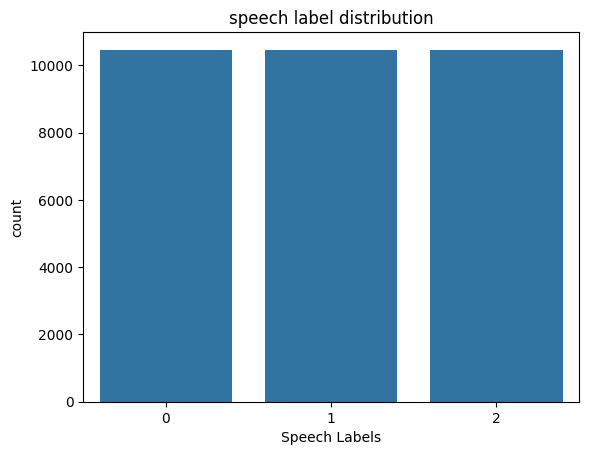

In [34]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [5]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


## Load RoBERTa Model

In [6]:
roberta = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(roberta)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta,
    num_labels=total_labels,
)

roberta_model.to(device)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1463.12it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [7]:
# Total number of parameters
roberta_params = sum(p.numel() for p in roberta_model.parameters() if p.requires_grad)
print(f"RoBERTa parameters: {roberta_params:,}")

RoBERTa parameters: 124,647,939


## Tokenizing Dataset

In [8]:
def tokenize(batch):
    return roberta_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_val = val_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024)

Map: 100%|██████████| 5886/5886 [00:00<00:00, 19221.58 examples/s]


In [9]:
tokenized_train, tokenized_val, tokenized_test

(Dataset({
     features: ['text', 'label', 'input_ids', 'attention_mask'],
     num_rows: 23541
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'attention_mask'],
     num_rows: 5886
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'attention_mask'],
     num_rows: 1962
 }))

In [ ]:
# remove the raw text column, we dont want a string
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [11]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 23541
})

## Model Training (Fine Tuning)

In [12]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

In [13]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/roberta"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [14]:
data_collator = DataCollatorWithPadding(roberta_tokenizer)

In [15]:
trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.499142,0.480175,0.784234,0.777052
2,0.402885,0.445357,0.804111,0.798204
3,0.349187,0.459138,0.805301,0.800453


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.68it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4416, training_loss=0.42342815537383593, metrics={'train_runtime': 1116.4885, 'train_samples_per_second': 63.255, 'train_steps_per_second': 3.955, 'total_flos': 9290929450102272.0, 'train_loss': 0.42342815537383593, 'epoch': 3.0})

In [ ]:
trainer.save_model(output_path)
roberta_tokenizer.save_pretrained(output_path)

## Model Evaluation

In [18]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test)
eval_results

{'eval_loss': 0.446000874042511,
 'eval_accuracy': 0.8160040774719673,
 'eval_f1': 0.8119962255214855,
 'eval_runtime': 9.4162,
 'eval_samples_per_second': 208.365,
 'eval_steps_per_second': 13.063,
 'epoch': 3.0}

In [19]:
pred = trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-2.1790137, -2.0953517,  4.7905016],
        [ 4.460383 , -1.7614872, -2.5996284],
        [ 1.414617 ,  2.792698 , -4.379595 ],
        ...,
        [ 1.5733668,  2.4792333, -4.2409806],
        [-1.8766878, -3.5339985,  5.8038087],
        [ 1.3007352,  2.8279426, -4.44557  ]],
       shape=(1962, 3), dtype=float32),
 array([2, 0, 0, ..., 1, 2, 1], shape=(1962,)))

In [20]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([2, 0, 1, ..., 1, 2, 1], shape=(1962,))

In [21]:
y_df = pd.DataFrame({
    "predicted": pred_labels,
    "true": pred.label_ids,
})
y_df.head()

,predicted,true
0,2,2
1,0,0
2,1,0
3,1,0
4,0,1


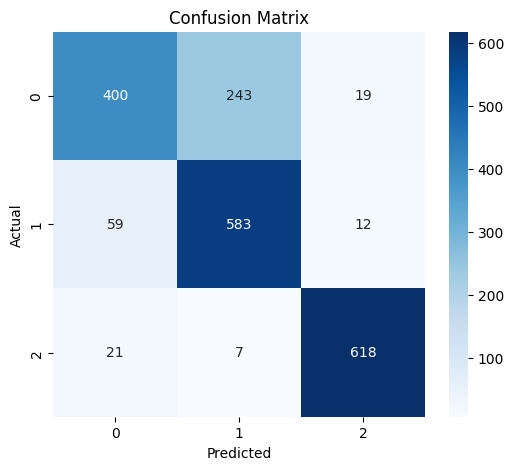

In [22]:
cm = confusion_matrix(pred.label_ids, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
report = classification_report(pred.label_ids, pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
0,0.833333,0.604230,0.700525,662.000000
1,0.699880,0.891437,0.784129,654.000000
2,0.952234,0.956656,0.954440,646.000000
accuracy,0.816004,0.816004,0.816004,0.816004
macro avg,0.828482,0.817441,0.813032,1962.000000
weighted avg,0.827998,0.816004,0.811996,1962.000000


# Inference Example

In [24]:
output_path = "./results/roberta"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1175.35it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [27]:
model.config.id2label = {0: "hate", 1: "offensive", 2: "neither"}
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

In [41]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

classifier("you are so stupid")

[{'label': 'hate', 'score': 0.9960263967514038}]